In [1]:
pip install keras

Note: you may need to restart the kernel to use updated packages.


In [2]:
pip install tensorflow

Note: you may need to restart the kernel to use updated packages.


In [3]:
!pip install opencv-python

In [4]:
!pip install opencv-contrib-python

In [5]:
import tensorflow as tf
import matplotlib.pyplot as plt
import cv2
import os
import numpy as np
from tensorflow.keras.preprocessing import image
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.optimizers import RMSprop
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Activation, Flatten, Conv2D, MaxPooling2D
import warnings
warnings.filterwarnings("ignore")

In [6]:
os.chdir(r'C:\Users\Karan\OneDrive\Desktop\Data_CNN')

In [7]:
os.getcwd()

'C:\\Users\\Karan\\OneDrive\\Desktop\\Data_CNN'

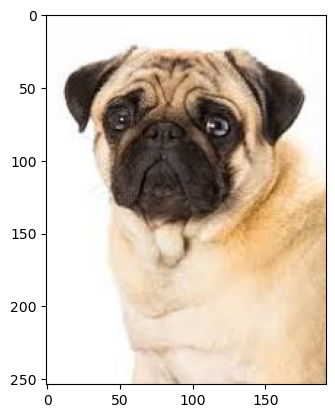

In [8]:
img = image.load_img(r'D:\Data_cnn 2\training\dog\1.jpeg')
plt.imshow(img)

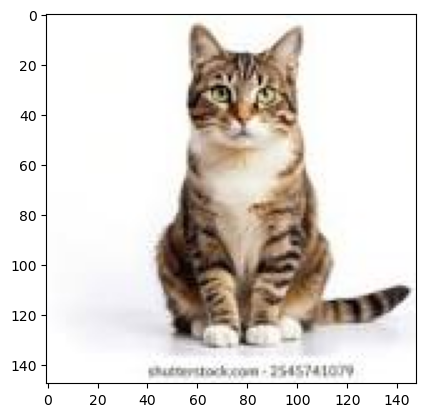

In [9]:
img = image.load_img(r"D:\Data_cnn 2\Testing\3.jpeg")
plt.imshow(img)

In [10]:
train = ImageDataGenerator(rescale= 1/255)
validation = ImageDataGenerator(rescale= 1/255)

In [11]:
tr_location = r"C:\Users\sarth\OneDrive\Desktop\Images\train"
val_location = r"C:\Users\sarth\OneDrive\Desktop\Images\validation"

In [12]:
train_data = train.flow_from_directory(tr_location,
                                      target_size=(200,200),
                                      batch_size= 3,
                                      class_mode= "binary")
valid_data = validation.flow_from_directory(val_location,
                                      target_size=(200,200),
                                      batch_size= 3,
                                      class_mode= "binary")

FileNotFoundError: [WinError 3] The system cannot find the path specified: 'C:\\Users\\sarth\\OneDrive\\Desktop\\Images\\train'

In [ ]:
train_data.class_indices

In [ ]:
model = tf.keras.models.Sequential([

    tf.keras.layers.Conv2D(16,(3,3),activation="relu",input_shape=(200,200,3)),
    tf.keras.layers.MaxPool2D(2,2),

    tf.keras.layers.Conv2D(32,(3,3),activation="relu"),
    tf.keras.layers.MaxPool2D(2,2),

    tf.keras.layers.Conv2D(64,(3,3), activation="relu"),
    tf.keras.layers.MaxPool2D(2,2),

    tf.keras.layers.Flatten(),

    tf.keras.layers.Dense(512,activation="relu"),

    tf.keras.layers.Dense(1,activation="sigmoid")])

In [ ]:

model.summary()

In [ ]:
model.compile(loss = "binary_crossentropy", optimizer= RMSprop(learning_rate= 0.001),
             metrics=["accuracy"])

In [ ]:
model.fit(train_data,steps_per_epoch=3, epochs= 10 , validation_data=valid_data)

In [ ]:
path = r"C:\Users\sarth\OneDrive\Desktop\Images\test"
for i in os.listdir(path):
    img = image.load_img(path+"/"+i,target_size=(200,200))
    plt.imshow(img)
    plt.show()
    
    x = image.img_to_array(img)
    x = np.expand_dims(x,axis = 0)
    pic = np.vstack([x])
    val = model.predict(pic)
    if val==0:
        print("Fish")
    else:
        print("Crocodile")